In [2]:
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

from pathlib import Path

from matplotlib import pyplot as plt
import torch

In [3]:
resnet = pd.read_csv('./resnet.csv')
tcn_binary = pd.read_csv('./tcn_binary.csv')
tcn_multi = pd.read_csv('./tcn_multi.csv')
tcn_cross_binary = pd.read_csv('./tcn_cross_binary.csv')
tcn_cross_multi = pd.read_csv('./tcn_cross_multi.csv')

In [ ]:
# bayes_class = pd.read_csv('./resnet.csv')
# bayes_knn = pd.read_csv('./tcn_binary.csv')
# bayes_parzen = pd.read_csv('./tcn_cross_binary.csv')
# logistic = pd.read_csv('./tcn_cross_multi.csv')
# majority = pd.read_csv('./tcn_multi.csv')

In [4]:
resnet.drop(columns=['f_measure', 'precision', 'recall'], inplace=True)
tcn_multi.drop(columns=['f_measure', 'precision', 'recall'], inplace=True)
tcn_cross_multi.drop(columns=['f_measure', 'precision', 'recall'], inplace=True)

In [5]:
map_columns = {
    'macro_f1': 'f_measure',
    'macro_recall': 'precision',
    'macro_precision': 'recall',
}

resnet.rename(columns=map_columns, inplace=True)
tcn_multi.rename(columns=map_columns, inplace=True)
tcn_cross_multi.rename(columns=map_columns, inplace=True)

# logistic['error_rate'] = 1 - logistic['subset_accuracy']

In [ ]:
# bayes_class = pd.read_csv('./outputs/original_bayes.csv')
# bayes_knn = pd.read_csv('./outputs/original_knn.csv')
# bayes_parzen = pd.read_csv('./outputs/original_parzen.csv')
# logistic = pd.read_csv('./outputs/original_logistic.csv')
# majority = pd.read_csv('./outputs/original_mv.csv')

In [ ]:
# bayes_class['fold'] = bayes_class['Name'].apply(lambda x: x.split('fold_')[-1])
# bayes_knn['fold'] = bayes_knn['Name'].apply(lambda x: x.split('fold_')[-1])
# bayes_parzen['fold'] = bayes_parzen['Name'].apply(lambda x: x.split('fold_')[-1])
# logistic['fold'] = logistic['Name'].apply(lambda x: x.split('fold_')[-1])
# majority['fold'] = majority['Name'].apply(lambda x: x.split('fold_')[-1])

In [ ]:
# bayes_class['fold'] = bayes_class['fold'].astype(int)
# bayes_knn['fold'] = bayes_knn['fold'].astype(int)
# bayes_parzen['fold'] = bayes_parzen['fold'].astype(int)
# logistic['fold'] = logistic['fold'].astype(int)
# majority['fold'] = majority['fold'].astype(int)

In [ ]:
# bayes_class.sort_values(by='fold', inplace=True)
# bayes_class.reset_index(inplace=True, drop=True)
# bayes_knn.sort_values(by='fold', inplace=True)
# bayes_knn.reset_index(inplace=True, drop=True)
# bayes_parzen.sort_values(by='fold', inplace=True)
# bayes_parzen.reset_index(inplace=True, drop=True)
# logistic.sort_values(by='fold', inplace=True)
# logistic.reset_index(inplace=True, drop=True)
# majority.sort_values(by='fold', inplace=True)
# majority.reset_index(inplace=True, drop=True)

In [18]:
models = {
    "SCDNN": resnet,
    "tcn_multi": tcn_multi,
    "tcn_cross_multi": tcn_cross_multi,
    "tcn_binary": tcn_binary,
    "tcn_cross_binary": tcn_cross_binary
}

def run_friedman_nemenyi(results, metric):
    arrays = [
        np.array(results[m][metric])
        for m in results
    ]

    stat, p = friedmanchisquare(*arrays)

    data = np.array(arrays).T

    nemenyi = sp.posthoc_nemenyi_friedman(data)
    nemenyi.index = models.keys()
    nemenyi.columns = models.keys()

    return stat, p, nemenyi.round(4)

In [19]:
# results = {
#     "Bayes Class": bayes_class,
#     "Bayes KNN": bayes_knn,
#     "Bayes Parzen": bayes_parzen,
#     "Logistic": logistic,
#     "Majority": majority
# }
results = {
    "SCDNN": resnet,
    "tcn_multi": tcn_multi,
    "tcn_cross_multi": tcn_cross_multi,
    "tcn_binary": tcn_binary,
    "tcn_cross_binary": tcn_cross_binary
}

In [31]:
stat_err, p_err, nemenyi_err = run_friedman_nemenyi(results, 'error_rate')
stat_prec, p_prec, nemenyi_prec = run_friedman_nemenyi(results, 'precision')
stat_rec, p_rec, nemenyi_rec = run_friedman_nemenyi(results, 'recall')
stat_f1, p_f1, nemenyi_f1 = run_friedman_nemenyi(results, 'f_measure')

In [32]:
friedman_results = pd.DataFrame({
    "Metric": ["Taxa de erro", "Precision", "Recall", "F1"],
    "Statistic": [stat_err, stat_prec, stat_rec, stat_f1],
    "p-value": [p_err, p_prec, p_rec, p_f1]
})

friedman_results["Decision"] = friedman_results["p-value"].apply(
    lambda p: "Reject $H_0$" if p < 0.001 else "Do not reject $H_0$"
)

friedman_results["p-value"] = friedman_results["p-value"].apply(
    lambda p: "<0.05" if p < 0.001 else f"{p:.4f}"
)

print(
    friedman_results.to_latex(
        index=False,
        escape=False,
        caption="Resultados do teste de Friedman ($\\alpha=0.05$)",
        label="tab:friedman"
    )
)

\begin{table}
\caption{Resultados do teste de Friedman ($\alpha=0.05$)}
\label{tab:friedman}
\begin{tabular}{lrll}
\toprule
Metric & Statistic & p-value & Decision \\
\midrule
Taxa de erro & 21.840000 & <0.05 & Reject $H_0$ \\
Precision & 32.000000 & <0.05 & Reject $H_0$ \\
Recall & 16.160000 & 0.0028 & Do not reject $H_0$ \\
F1 & 26.560000 & <0.05 & Reject $H_0$ \\
\bottomrule
\end{tabular}
\end{table}



In [33]:
metrics = ['error_rate', 'precision', 'recall', 'f_measure']

model_names = list(models.keys())

for m in metrics:
    rows = []

    _, _, nemenyi = run_friedman_nemenyi(results, m)

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            p = nemenyi.iloc[i, j]

            rows.append({
                "Comparison": f"{model_names[i]} vs {model_names[j]}",
                "p-value": p,
                "Significant": "Yes" if p < 0.05 else "No"
            })

    pairwise = pd.DataFrame(rows)

    print(
        pairwise.to_latex(
            index=False,
            float_format="%.4g",
            caption=f"Comparações par-a-par do teste de Nemenyi para {m}",
            label="tab:nemenyi_pairs"
        )
    )

\begin{table}
\caption{Comparações par-a-par do teste de Nemenyi para error_rate}
\label{tab:nemenyi_pairs}
\begin{tabular}{lrl}
\toprule
Comparison & p-value & Significant \\
\midrule
SCDNN vs tcn_multi & 0.0808 & No \\
SCDNN vs tcn_cross_multi & 0.0037 & Yes \\
SCDNN vs tcn_binary & 0.0001 & Yes \\
SCDNN vs tcn_cross_binary & 0.1571 & No \\
tcn_multi vs tcn_cross_multi & 0.86 & No \\
tcn_multi vs tcn_binary & 0.3513 & No \\
tcn_multi vs tcn_cross_binary & 0.9986 & No \\
tcn_cross_multi vs tcn_binary & 0.9153 & No \\
tcn_cross_multi vs tcn_cross_binary & 0.708 & No \\
tcn_binary vs tcn_cross_binary & 0.2109 & No \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Comparações par-a-par do teste de Nemenyi para precision}
\label{tab:nemenyi_pairs}
\begin{tabular}{lrl}
\toprule
Comparison & p-value & Significant \\
\midrule
SCDNN vs tcn_multi & 0.2758 & No \\
SCDNN vs tcn_cross_multi & 0.4357 & No \\
SCDNN vs tcn_binary & 0 & Yes \\
SCDNN vs tcn_cross_binary & 0.0007 & Yes \

# Curva de aprendizagem

In [8]:
data = {
    'KNN': './outputs/knn_learning.csv',
    'Parzen': './outputs/parzen_learning.csv',
    'LR': './outputs/lr_learning.csv',
    'CBG': './outputs/CBG_learning.csv',
    'MV': './outputs/mv_learning.csv',
}

In [9]:
for clf_name, folder in data.items():

    df = pd.read_csv(folder)

    summary = (
        df.groupby("frac")
        .agg(
            train_mean=("train_metrics.f_measure", "mean"),
            train_std=("train_metrics.f_measure", "std"),
            test_mean=("test_metrics.f_measure", "mean"),
            test_std=("test_metrics.f_measure", "std"),
        )
        .reset_index()
        .sort_values("frac")
    )

    x = summary["frac"] * 100

    plt.figure(figsize=(8, 5))

    plt.plot(
        x,
        summary["train_mean"],
        marker="o",
        label="Treinamento",
    )

    plt.plot(
        x,
        summary["test_mean"],
        marker="s",
        label="Teste",
    )

    plt.fill_between(
        x,
        summary["train_mean"] - summary["train_std"],
        summary["train_mean"] + summary["train_std"],
        alpha=0.2,
    )

    plt.fill_between(
        x,
        summary["test_mean"] - summary["test_std"],
        summary["test_mean"] + summary["test_std"],
        alpha=0.2,
    )

    plt.title(clf_name)
    plt.xlabel("% dos dados de treinamento")
    plt.ylabel("F1-score")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        f"{clf_name}_learning_curve.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.close()

# Cluster

In [3]:
df = pd.read_csv('./outputs/n_cluster.csv')

In [4]:
df

,Name,silhouette_score,f_measure,adjusted_rand_score,n_clusters
0,modeling_structure_n_clusters: 3,0.205938,0.601618,0.116153,3
1,modeling_structure_n_clusters: 2,0.177552,0.447292,0.037678,2
2,modeling_structure_n_clusters: 4,0.176979,0.606195,0.099365,4
3,modeling_structure_n_clusters: 5,0.169377,0.695635,0.125116,5
4,modeling_structure_n_clusters: 6,0.160982,0.737914,0.134616,6


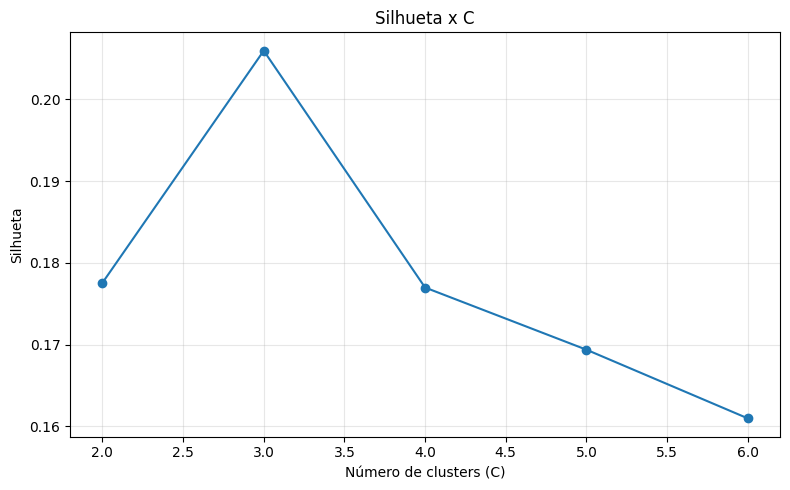

In [20]:
df = df.sort_values("n_clusters")

fig, ax1 = plt.subplots(figsize=(8, 5))

# Silhouette
ax1.plot(
    df["k"],
    df["silhouette_score"],
    marker="o",
    label="Silhouette"
)
ax1.set_xlabel("Número de clusters (C)")
ax1.set_ylabel("Silhueta")
ax1.grid(True, alpha=0.3)

# Legenda conjunta
lines = ax1.get_lines()
labels = [l.get_label() for l in lines]

plt.title("Silhueta x C")
plt.tight_layout()
plt.savefig(
    f"silhueta_c.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [55]:
path_params = 'runs/KCM_K_GH_ionosphere_20260606_202531/tunning_model.pt'
path_preds = 'runs/KCM_K_GH_ionosphere_20260606_202531/tunning_predictions.pt'

In [56]:
import torch


checkpoint = torch.load(path_params)
preds = torch.load(path_preds, weights_only=False)

In [57]:
checkpoint.keys()

dict_keys(['prototypes', 's2', 'labels'])

In [58]:
G = checkpoint['prototypes']

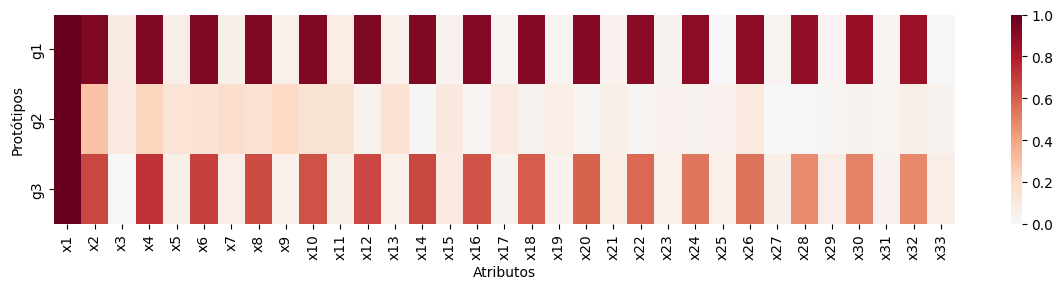

In [75]:
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns


proto_norm = MinMaxScaler().fit_transform(
    G.cpu().numpy().T
).T

proto_df = pd.DataFrame(
    proto_norm,
    index=[f"g{i+1}" for i in range(G.shape[0])],
    columns=[f"x{i+1}" for i in range(G.shape[1])]
)

plt.figure(figsize=(12, 3))

sns.heatmap(
    proto_df,
    cmap="RdBu_r",
    center=0
)

plt.xlabel("Atributos")
plt.ylabel("Protótipos")
plt.tight_layout()
plt.show()

In [60]:
s = checkpoint['s2']

In [73]:
s

tensor([5.6605e-05, 1.4725e+00, 1.1837e+00, 1.3462e+00, 1.2881e+00, 9.7810e-01,
        2.0821e+00, 9.1332e-01, 1.0795e+00, 1.0594e+00, 1.5620e+00, 7.0999e-01,
        1.4598e+00, 6.6980e-01, 1.6096e+00, 9.0200e-01, 1.9547e+00, 1.0439e+00,
        1.9497e+00, 7.4196e-01, 2.0058e+00, 9.8760e-01, 2.4639e+00, 1.0374e+00,
        2.2997e+00, 9.1247e-01, 2.0637e+00, 1.2646e+00, 2.4843e+00, 1.0099e+00,
        2.6937e+00, 1.1688e+00, 2.6998e+00])

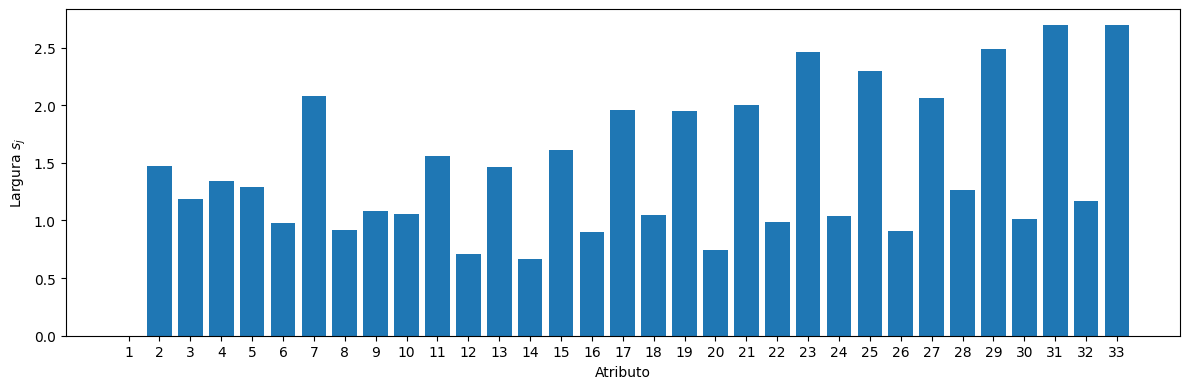

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.bar(
    range(1, len(s)+1),
    s.cpu().numpy()
)

plt.xlabel("Atributo")
plt.ylabel("Largura $s_j$")
plt.xticks(range(1, len(s)+1))
plt.tight_layout()

plt.show()

In [62]:
preds.keys()

dict_keys(['train_y_true', 'train_y_scores'])

In [72]:
preds['train_y_scores'][1].cpu().numpy()

array([2, 1, 2, 1, 2, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 1, 2, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 2, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 2, 1, 2, 0, 2, 0, 2, 0, 0, 0, 2, 1, 2, 2, 2, 2,
       2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       2, 1, 2, 1, 1, 1, 2, 2, 1, 0, 2, 0, 1, 2, 1, 2, 0, 0, 1, 0, 2, 1,
       2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 1, 2, 1, 1, 0, 0, 0, 1, 2, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 2, 0, 2, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0,
       1, 0, 0, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 2, 1, 0, 0, 1, 0, 2, 0, 1,
       0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 0, 0, 2, 0, 0, 1, 2, 1, 2, 1, 0,
       1, 0, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 1,

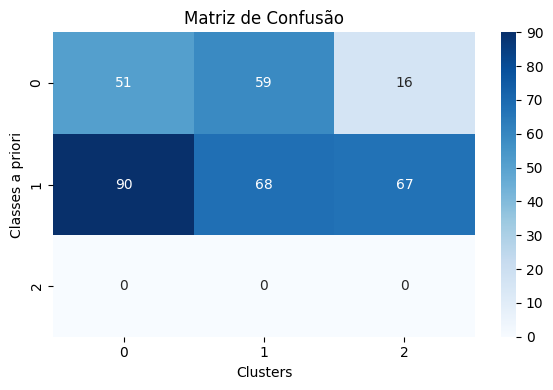

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(preds['train_y_true'].to_numpy(), preds['train_y_scores'][1].cpu().numpy())

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Clusters")
plt.ylabel("Classes a priori")
plt.title("Matriz de Confusão")

plt.tight_layout()
plt.show()

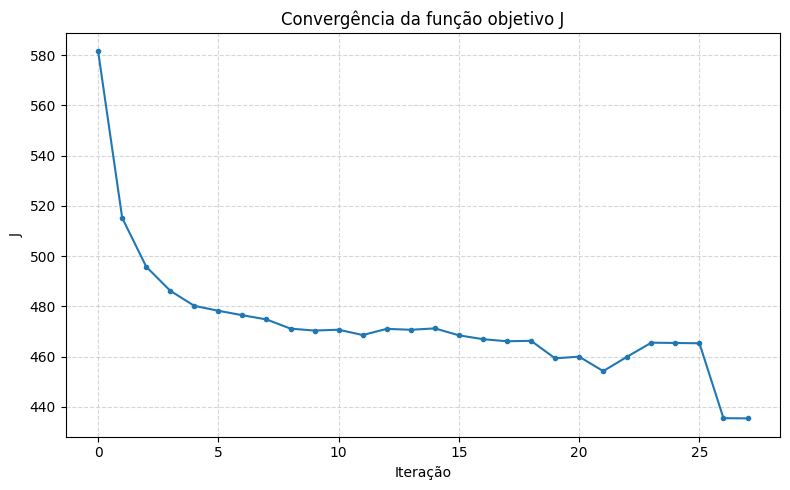

In [54]:
df = pd.read_csv("./outputs/obj.csv")

loss = "modeling_structure_n_clusters: 3 - train_loss"

plt.figure(figsize=(8,5))

plt.plot(

    df["iteration"],

    df[loss],

    marker="o",

    markersize=3

)

plt.xlabel("Iteração")

plt.ylabel(r"J")

plt.title(r"Convergência da função objetivo J")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [21]:
path = 'runs/logistic_regression_ionosphere_20260606_214652/tunning_predictions.pt'
preds = torch.load(path, weights_only=False)

In [23]:
preds.keys()

dict_keys(['train_y_true', 'train_y_scores', 'test_y_true', 'test_y_scores', 'train_idx', 'test_idx'])

In [24]:
preds['test_y_true']

[0, 0, 0, 1, 1, ..., 1, 1, 1, 1, 1]
Length: 35
Categories (2, int64): [0, 1]

In [27]:
y_pred = (preds['test_y_scores'].detach().cpu().numpy() >= 0.5).astype(int)

In [29]:
from sklearn.metrics import accuracy_score


acc = accuracy_score(preds['test_y_true'], y_pred)

In [33]:
from sklearn.metrics import f1_score


f1_score(preds['test_y_true'], y_pred, average="binary", zero_division=0)

0.8627450980392157

In [31]:
1 - acc

0.19999999999999996

In [ ]:
0.0967

# Model

In [34]:
import logging
logger = logging.getLogger(__name__)

In [83]:
import yaml

from modeling.structure.factory import ModelingStructureFactory

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

with open('./runs/tcn_ptbxl_20260625_210038/config.yaml', "r") as f:
    config = yaml.safe_load(f)

device = get_device()
model = ModelingStructureFactory().get(config, logger, device)
model.compile()

/Users/mauriciosightman/Documents/work/machine_learing_2026/.venv/lib/python3.14/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [84]:
from data_loader.factory import DataLoaderFactory
from data_pre_processing.factory import DataPreProcessingFactory


dataset_loader = DataLoaderFactory().get(config, logger, device)
pre_processing = DataPreProcessingFactory().get(config, logger)
X, y_true = pre_processing.initialize(dataset_loader)

Data Loading start!
---------------------------


In [85]:
def create_fold_split(X, Y, test_fold):
        """
        Parameters
        ----------
        X : np.ndarray
            ECG signals.
        Y : pd.DataFrame
            Must contain 'strat_fold' and the target column.
        test_fold : int
            Fold to use as the test set (1-10).

        Returns
        -------
        X_split : tuple
        y_split : tuple
        """

        # Use the next fold for validation
        val_fold = test_fold - 1 if test_fold > 1 else 10

        train_mask = (Y.strat_fold != test_fold) & (Y.strat_fold != val_fold)

        val_mask = Y.strat_fold == val_fold
        test_mask = Y.strat_fold == test_fold

        classes = [
            "NORM",
            "MI",
            "STTC",
            "CD",
            "HYP",
        ]
        class_to_idx = {c: i for i, c in enumerate(classes)}
        num_classes = 5
        labels = Y["label"].map(class_to_idx).values
        y_onehot = np.eye(num_classes)[labels]

        X_train = X[train_mask.values]
        X_val = X[val_mask.values]
        X_test = X[test_mask.values]

        # Replace "target" with your label column
        y_train = np.argmax(y_onehot[train_mask], axis=1)
        y_val = np.argmax(y_onehot[val_mask], axis=1)
        y_test = np.argmax(y_onehot[test_mask], axis=1)

        return (
            (X_train, X_val, X_test),
            (y_train, y_val, y_test),
        )

In [86]:
X_split, y_split = create_fold_split(X,y_true,10,)

In [87]:
from torch.utils.data import DataLoader, Dataset

def normalize_signals(
        X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        mean = X_train.mean(axis=(0, 2), keepdims=True).astype(np.float32)
        std = X_train.std(axis=(0, 2), keepdims=True).astype(np.float32)
        std = np.where(std < 1e-6, 1.0, std)

        return (
            ((X_train - mean) / std).astype(np.float32, copy=False),
            ((X_val - mean) / std).astype(np.float32, copy=False),
            ((X_test - mean) / std).astype(np.float32, copy=False),
        )

def create_loaders(
        X: np.ndarray, y: pd.DataFrame
    ):
        batch_size = 64

        X_train, X_val, X_test = X
        y_train, y_val, y_test = y

        normalize = True
        if normalize:
            X_train, X_val, X_test = normalize_signals(X_train, X_val, X_test)

        def convert(label):
            converted_label = label.astype(np.float32).reshape(-1, 1)
            # if self.output_size == 1:
            #     converted_label = (
            #         np.where(label == 0, 0, 1).astype(np.float32).reshape(-1, 1)
            #     )
            return converted_label

        class dataset(Dataset):

            def __init__(self, signal, label):

                self.data = signal
                self.label = label

            def __len__(self):
                return len(self.data)

            def __getitem__(self, idx):
                if torch.is_tensor(idx):
                    idx = idx.tolist()
                ecg = torch.from_numpy(self.data[idx].astype(np.float32))
                target = torch.from_numpy(self.label[idx])  # .type(torch.long)

                sample = (ecg, target)
                return sample

        ### --------------------------------
        # convert target to tensor

        converted_y_train = convert(y_train)
        converted_y_test = convert(y_test)
        converted_y_val = convert(y_val)

        ### -------------------------------
        # create dataset

        trainset = dataset(signal=X_train, label=converted_y_train)
        testset = dataset(signal=X_test, label=converted_y_test)
        valset = dataset(signal=X_val, label=converted_y_val)

        ### --------------------------------
        # create dataloader

        train_loader = DataLoader(
            dataset=trainset,
            batch_size=batch_size,
            shuffle=True,
        )
        test_loader = DataLoader(
            dataset=testset,
            batch_size=batch_size,
            shuffle=False,
        )
        val_loader = DataLoader(
            dataset=valset,
            batch_size=batch_size,
            shuffle=False,
        )

        return train_loader, val_loader, test_loader

In [88]:
train_loader, val_loader, test_loader = create_loaders(X_split, y_split)
y_train = y_split[0]

In [89]:
from torch import nn


output_size = 1
criterion = nn.BCELoss()

In [90]:
def validate(
        model, val_loader: DataLoader) -> float:
        """ "
        Inference model to get validation loss

        args:
            model: pytorch model
            val_loader: data
            epoch: current epoch

        returns:
            validation loss
        """

        model.eval()
        val_loss = 0
        y_pred = []
        y_true = []

        with torch.no_grad():
            for i, (data, target) in enumerate(val_loader):
                data = data.to(device)
                target_b = torch.tensor(
                    np.where(target == 0, 0, 1).astype(np.float32).reshape(-1)
                ).to(device)

                out = model.forward(data)
                if output_size == 1:
                    out = out.reshape(-1)

                loss = criterion(out, target_b)
                val_loss += loss.item()

                y_pred.append(out)
                y_true.append(target)

        val_loss = val_loss / len(val_loader)

        y_pred = torch.cat(y_pred, dim=0)
        y_true = torch.cat(y_true, dim=0)

        return val_loss, (y_true, y_pred)

In [91]:
val_loss, (y_true, y_pred) = validate(model, test_loader)

In [92]:
y_true

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [3.],
        [1.]])

In [93]:
y_pred

tensor([0.0591, 0.3153, 0.2750,  ..., 0.6601, 0.8727, 0.9180], device='mps:0')

In [94]:
y_true = y_true.squeeze().long().cpu()
y_pred_class = (y_pred >= 0.5).long().cpu()

mask = (y_pred_class == 1)

classes, counts = torch.unique(y_true[mask], return_counts=True)

for c, n in zip(classes.tolist(), counts.tolist()):
    print(f"Classe verdadeira {c}: {n}")

Classe verdadeira 0: 88
Classe verdadeira 1: 196
Classe verdadeira 2: 212
Classe verdadeira 3: 149
Classe verdadeira 4: 27


In [95]:
y_true = y_true.squeeze().long().to(y_pred.device)
y_pred_class = (y_pred >= 0.5).long()

mask = (y_pred_class == 1)

classes, counts = torch.unique(y_true[mask], return_counts=True)

In [96]:
y_pred_class = (y_pred >= 0.5).long()
y_true = y_true.squeeze().long()

for c in torch.unique(y_true):
    mask = (y_true == c)
    n_total = mask.sum().item()
    n_pred1 = (y_pred_class[mask] == 1).sum().item()
    print(f"Classe {c.item()}: {n_pred1}/{n_total} ({100*n_pred1/n_total:.2f}%) previstos como 1")

Classe 0: 88/912 (9.65%) previstos como 1
Classe 1: 196/256 (76.56%) previstos como 1
Classe 2: 212/242 (87.60%) previstos como 1
Classe 3: 149/184 (80.98%) previstos como 1
Classe 4: 27/56 (48.21%) previstos como 1


In [97]:
y_true_bin = (y_true.squeeze() != 0).long().cpu().numpy()
y_pred_bin = (y_pred >= 0.5).long().cpu().numpy()

precision = precision_score(y_true_bin, y_pred_bin)
recall = recall_score(y_true_bin, y_pred_bin)
f1 = f1_score(y_true_bin, y_pred_bin)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.8690
Recall:    0.7913
F1-score:  0.8284
